In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.lines import Line2D
from nettcr.models import NetTCR
from scipy import stats
from sklearn.metrics import roc_auc_score

from tcr_antigen_prediction.models import TCRStructMap

In [2]:
SIGNIFICANCE_LEVEL = 0.05

In [3]:
model_names = ('TCRStructMap', 'NetTCR')
data_splits = ('random', 'peptide', 'pMHC')

base_dir = Path('data/processed/')

predictions = []
for data_split in data_splits:
    sequences = pd.read_csv(f'data/interim/sequences_{data_split}_split.csv', index_col='index')

    for model_name in model_names:
        prediction_set = pd.read_csv(str(base_dir / f'{model_name}_predictions_on_sequences_{data_split}_split.csv'))

        prediction_set['model_name'] = model_name
        prediction_set['data_split'] = data_split

        prediction_set = prediction_set.merge(sequences, how='left', left_on='index', right_index=True)

        predictions.append(prediction_set)

predictions = pd.concat(predictions).reset_index(drop=True)
predictions = predictions[predictions['fold'] == predictions['sub_model_number']].reset_index(drop=True)

In [4]:
overall_roc_auc = predictions.groupby(['data_split', 'model_name']).apply(
    lambda group: roc_auc_score(group['label'], group['prediction']), include_groups=False
)
overall_roc_auc.name = 'roc_auc_score'

overall_roc_auc = overall_roc_auc.reindex(
    pd.MultiIndex.from_product(
        [data_splits, model_names],
        names=['data_split', 'model_name'],
    )
)

overall_roc_auc

data_split  model_name  
random      TCRStructMap    0.876085
            NetTCR          0.775211
peptide     TCRStructMap    0.666831
            NetTCR          0.524658
pMHC        TCRStructMap    0.471265
            NetTCR          0.452818
Name: roc_auc_score, dtype: float64

## Model Size

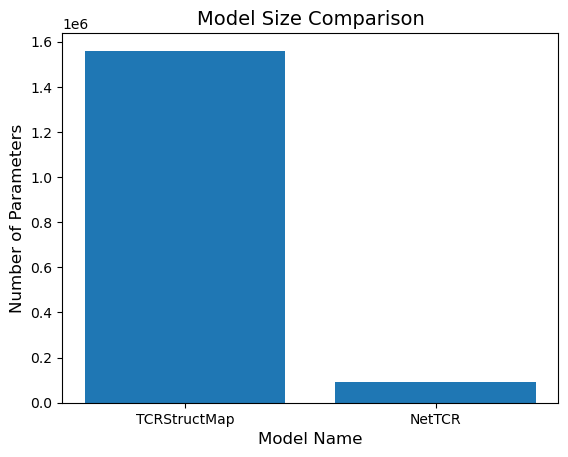

TCRStructMap size: 1559983
NetTCR size: 92529


In [5]:
def count_parameters(model: torch.nn.Module) -> int:
    """Count the number of parmeters in a pytorch model."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model_sizes = [
    (model_name, count_parameters(model))
    for model_name, model in (('TCRStructMap', TCRStructMap()), ('NetTCR', NetTCR()))
]
plt.bar(x=[model_name for model_name, _ in model_sizes], height=[model_size for _, model_size in model_sizes])

plt.title('Model Size Comparison', fontsize=14)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Number of Parameters', fontsize=12)

plt.show()

print('\n'.join([f'{model_name} size: {model_size}' for model_name, model_size in model_sizes]))

## Bootstrap ROC-AUC

In [6]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 500

indices = predictions['index'].unique()
rng = np.random.default_rng(123)

samples_metric_scores = []
for sample_num in range(1, NUM_SAMPLES + 1):
    sample_indices = rng.choice(indices, SAMPLE_SIZE)

    sample = predictions[predictions['index'].isin(sample_indices)]

    for (model_name, data_split), group in sample.groupby(['model_name', 'data_split']):
        score = roc_auc_score(group['label'], group['prediction'])
        samples_metric_scores.append(
            {
                'sample_num': sample_num,
                'data_split': data_split,
                'model_name': model_name,
                'roc_auc_score': score,
            }
        )

samples_metric_scores = pd.DataFrame(samples_metric_scores)

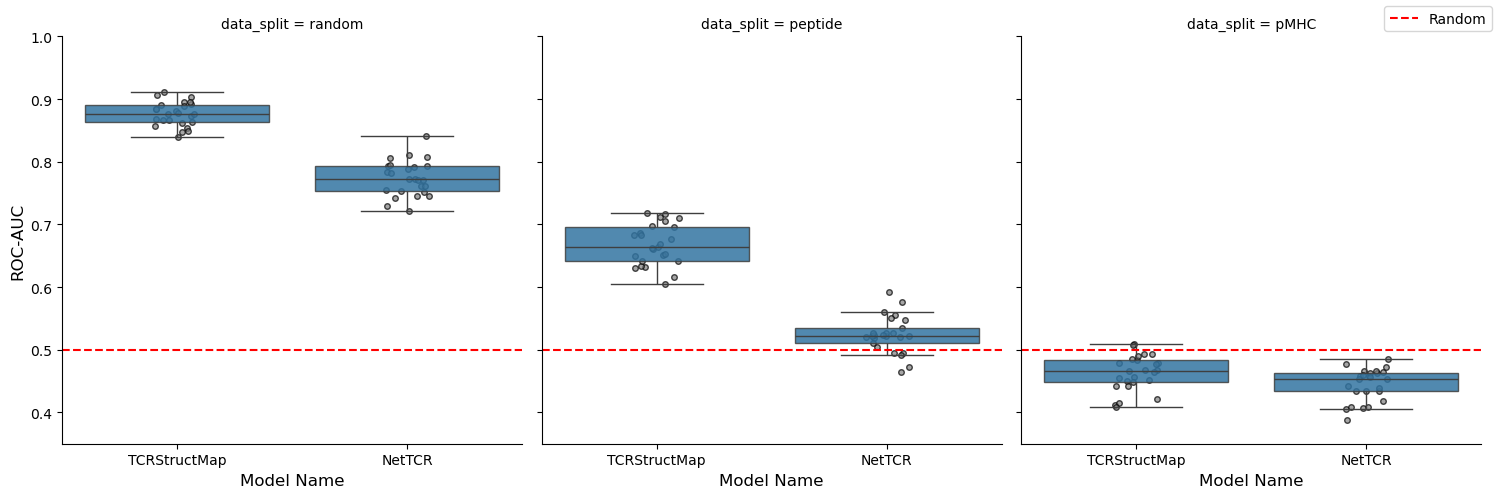

In [7]:
grid = sns.FacetGrid(samples_metric_scores, col='data_split', col_order=data_splits, sharex=False, height=5)

grid.map_dataframe(
    sns.boxplot,
    x='model_name',
    y='roc_auc_score',
    order=model_names,
    showfliers=False,
    boxprops={'alpha': 0.85},
    zorder=1,
)
grid.map_dataframe(
    sns.stripplot,
    x='model_name',
    y='roc_auc_score',
    order=model_names,
    color='grey',
    marker='o',
    size=4,
    edgecolor='black',
    linewidth=1,
    alpha=0.70,
    zorder=0,
)

grid.refline(y=0.5, color='red')
refline_handle = Line2D([0], [0], color='red', linestyle='--', label='Random')
grid.figure.legend(handles=[refline_handle], loc='upper right')

grid.set(ylim=(0.35, 1.0))
grid.set_axis_labels('Model Name', 'ROC-AUC', fontsize=12)

plt.savefig('report/figures/comparison_TCRStructMap_NetTCR.svg')
plt.show()

In [8]:
metric_scores_agg = pd.concat(
    [
        overall_roc_auc,
        samples_metric_scores.groupby(['data_split', 'model_name'])['roc_auc_score']
        .agg(['std'])
        .sort_index(ascending=False),
    ],
    axis=1,
)

norm_val = stats.norm.ppf(1 - SIGNIFICANCE_LEVEL / 2)
metric_scores_agg['ci'] = metric_scores_agg.apply(
    lambda row, norm_val=norm_val: (
        row['roc_auc_score'] - norm_val * row['std'],
        row['roc_auc_score'] + norm_val * row['std'],
    ),
    axis=1,
)

metric_scores_agg = metric_scores_agg.reindex(
    pd.MultiIndex.from_product(
        [data_splits, model_names],
        names=['data_split', 'model_name'],
    )
)

metric_scores_agg

roc_auc_score       std  \
data_split model_name                              
random     TCRStructMap       0.876085  0.019209   
           NetTCR             0.775211  0.028028   
peptide    TCRStructMap       0.666831  0.032473   
           NetTCR             0.524658  0.029321   
pMHC       TCRStructMap       0.471265  0.028396   
           NetTCR             0.452818  0.026165   

                                                               ci  
data_split model_name                                              
random     TCRStructMap  (0.8384358432460358, 0.9137340200255891)  
           NetTCR         (0.720277923896987, 0.8301439047589794)  
peptide    TCRStructMap   (0.6031860937066418, 0.730476027153012)  
           NetTCR        (0.4671894522130795, 0.5821264370421424)  
pMHC       TCRStructMap  (0.4156106231659526, 0.5269193794332403)  
           NetTCR        (0.4015344111526581, 0.5041006683757264)

In [9]:
def calculate_differences(df: pd.DataFrame) -> pd.DataFrame:
    groups = list(df.groupby('model_name'))
    groups = sorted(groups, key=lambda item: model_names.index(item[0]))

    differences = {
        'group_name_i': [],
        'group_name_j': [],
        'difference_roc_auc': [],
    }
    for i, (group_name_i, group_i) in enumerate(groups[:-1]):
        for group_name_j, group_j in groups[i + 1 :]:
            differences['difference_roc_auc'].append(
                group_i['roc_auc_score'].iloc[0] - group_j['roc_auc_score'].iloc[0]
            )

            differences['group_name_i'].append(group_name_i)
            differences['group_name_j'].append(group_name_j)

    return pd.DataFrame(differences).set_index(['group_name_i', 'group_name_j'])

In [10]:
overall_roc_auc_difference = (
    overall_roc_auc.reset_index().groupby('data_split').apply(calculate_differences, include_groups=False)
)

samples_metric_scores_differences = (
    samples_metric_scores.groupby(['sample_num', 'data_split'])
    .apply(calculate_differences, include_groups=False)
    .groupby(['data_split', 'group_name_i', 'group_name_j'])
    .agg(['std'])
)
samples_metric_scores_differences.columns = ['_'.join(column) for column in samples_metric_scores_differences.columns]


metric_scores_difference = pd.concat([overall_roc_auc_difference, samples_metric_scores_differences], axis=1)


norm_value = stats.t.ppf((2 - SIGNIFICANCE_LEVEL) / 2, NUM_SAMPLES - 1)
metric_scores_difference['ci'] = metric_scores_difference.apply(
    lambda row, norm_value=norm_value: (
        row['difference_roc_auc'] - norm_value * row['difference_roc_auc_std'],
        row['difference_roc_auc'] + norm_value * row['difference_roc_auc_std'],
    ),
    axis=1,
)

metric_scores_difference = metric_scores_difference.sort_index(
    level='data_split', key=lambda index: index.map(data_splits.index)
)

metric_scores_difference

,,,difference_roc_auc,difference_roc_auc_std,ci
data_split,group_name_i,group_name_j,,,
random,TCRStructMap,NetTCR,0.100874,0.027986,"(0.04311433232932853, 0.15863370228633006)"
peptide,TCRStructMap,NetTCR,0.142173,0.031486,"(0.07718933365372059, 0.20715689795071124)"
pMHC,TCRStructMap,NetTCR,0.018447,0.021791,"(-0.026527441736019057, 0.06342236480682739)"


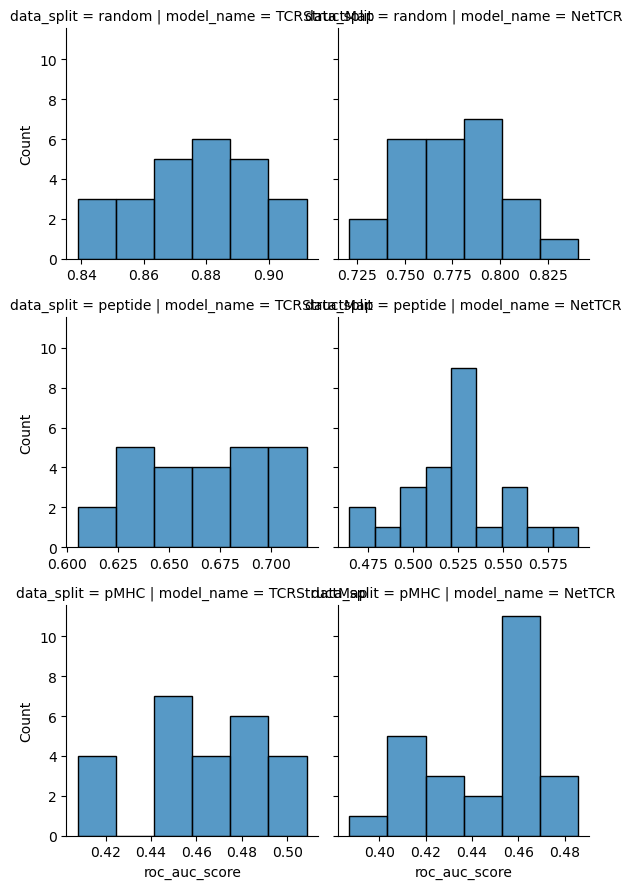

In [11]:
grid = sns.FacetGrid(
    samples_metric_scores,
    row='data_split',
    col='model_name',
    row_order=data_splits,
    col_order=model_names,
    sharex=False,
)
grid.map_dataframe(sns.histplot, x='roc_auc_score')

plt.show()

In [12]:
for data_split, data_group in samples_metric_scores.set_index('sample_num').sort_index().groupby('data_split'):
    print(data_split)
    print(
        stats.ttest_rel(
            data_group.query("model_name == 'TCRStructMap'")['roc_auc_score'],
            data_group.query("model_name == 'NetTCR'")['roc_auc_score'],
            alternative='greater',
        )
    )

    print()

pMHC
TtestResult(statistic=np.float64(4.148521862974196), pvalue=np.float64(0.00018089579144915609), df=np.int64(24))

peptide
TtestResult(statistic=np.float64(22.813321976373004), pvalue=np.float64(4.429610003763589e-18), df=np.int64(24))

random
TtestResult(statistic=np.float64(18.29891634313508), pvalue=np.float64(6.66343198786044e-16), df=np.int64(24))

